In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

stock_symbol = "AAPL"
start_date = "2013-01-01"
end_date = "2023-01-01"

stock_data = yf.download(stock_symbol, start=start_date, end=end_date,auto_adjust=False )

[*********************100%***********************]  1 of 1 completed


In [ ]:
# Check basic info
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2518 entries, 2013-01-02 to 2022-12-30
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  2518 non-null   float64
 1   (Close, AAPL)      2518 non-null   float64
 2   (High, AAPL)       2518 non-null   float64
 3   (Low, AAPL)        2518 non-null   float64
 4   (Open, AAPL)       2518 non-null   float64
 5   (Volume, AAPL)     2518 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 137.7 KB


In [ ]:
# Check for missing or duplicated values
print(stock_data.isnull().sum())
print(stock_data.duplicated().sum())

Price      Ticker
Adj Close  AAPL      0
Close      AAPL      0
High       AAPL      0
Low        AAPL      0
Open       AAPL      0
Volume     AAPL      0
dtype: int64
0


Line Chart of Closing Prices

Purpose: To understand long-term trends and patterns. This shows the overall growth trend and major movements over time — essential for long-term investors.

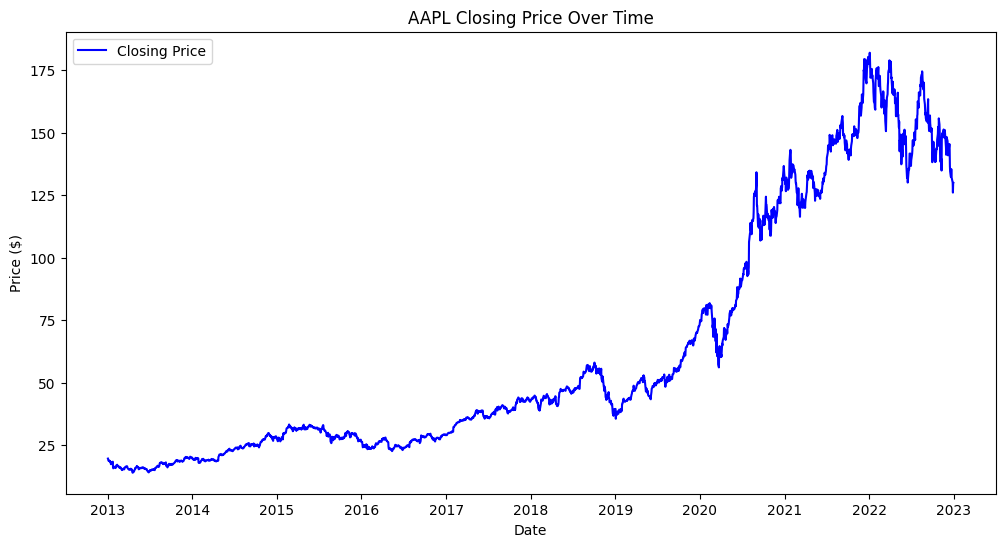

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(stock_data['Close'], label='Closing Price', color='blue')
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()


Moving Averages

Purpose: To smooth out short-term fluctuations and reveal the underlying trend. Common in technical analysis — e.g., a “Golden Cross” (50-day MA crosses above 200-day MA) indicates potential upward trend.

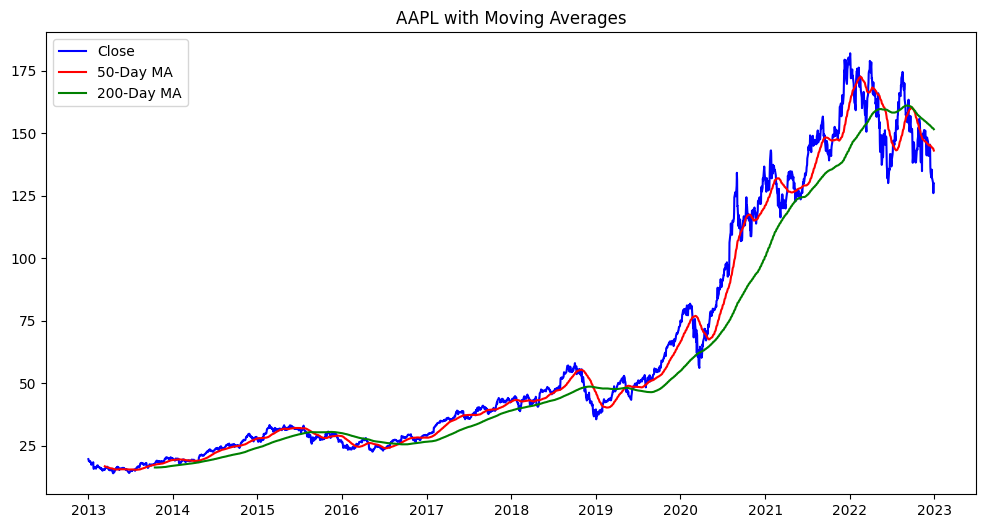

In [ ]:
stock_data['MA50'] = stock_data['Close'].rolling(50).mean()
stock_data['MA200'] = stock_data['Close'].rolling(200).mean()

plt.figure(figsize=(12,6))
plt.plot(stock_data['Close'], label='Close', color='blue')
plt.plot(stock_data['MA50'], label='50-Day MA', color='red')
plt.plot(stock_data['MA200'], label='200-Day MA', color='green')
plt.title('AAPL with Moving Averages')
plt.legend()
plt.show()

Daily Returns Distribution

Purpose: To understand volatility and risk. Helps analyze risk profile — a wider distribution means higher volatility.

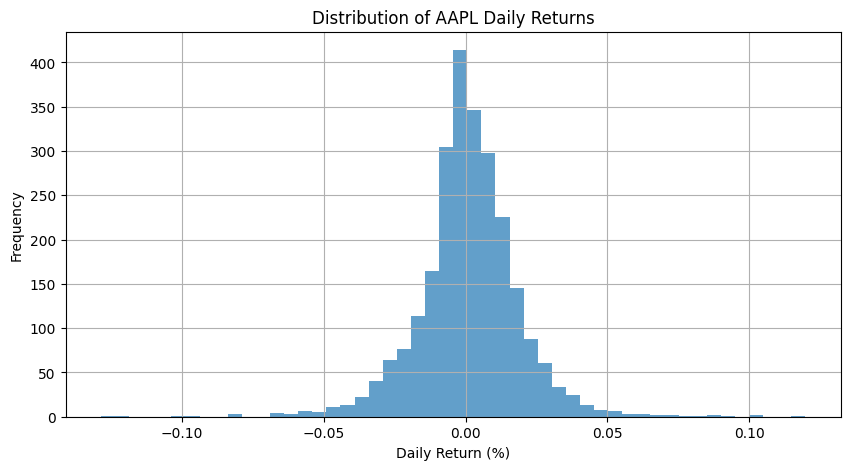

In [ ]:
stock_data['Daily Return'] = stock_data['Close'].pct_change()

plt.figure(figsize=(10,5))
stock_data['Daily Return'].hist(bins=50, alpha=0.7)
plt.title('Distribution of AAPL Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.show()

Rolling Volatility / Rolling Mean

Purpose: To analyze time-varying volatility. Volatility indicates uncertainty or market reaction — key for risk management.

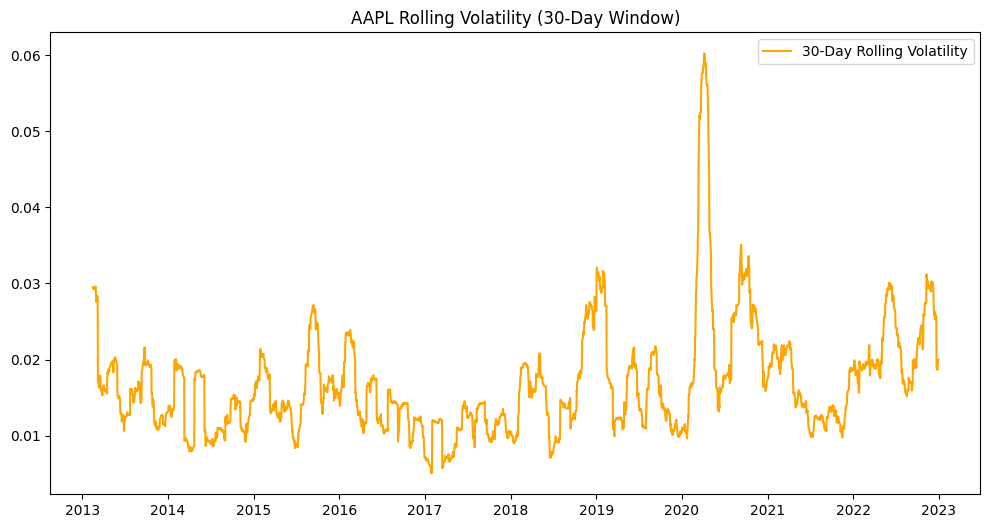

In [ ]:
stock_data['Rolling Volatility'] = stock_data['Daily Return'].rolling(30).std()

plt.figure(figsize=(12,6))
plt.plot(stock_data['Rolling Volatility'], label='30-Day Rolling Volatility', color='orange')
plt.title('AAPL Rolling Volatility (30-Day Window)')
plt.legend()
plt.show()

Correlation Heatmap (if comparing multiple stocks)

Purpose: To check how correlated close price of AAPL is with other tech stocks. Useful in portfolio diversification — highly correlated stocks add similar risk.

/tmp/ipython-input-3389266579.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed


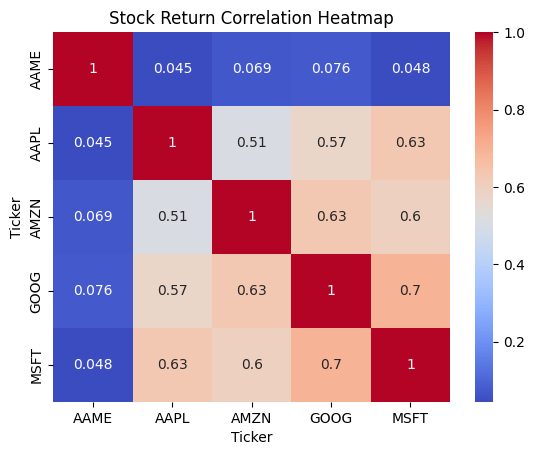

In [ ]:
import seaborn as sns
stocks = ['AAPL','MSFT','GOOG','AMZN','AAME']
data = yf.download(stocks, start=start_date, end=end_date)['Close']
sns.heatmap(data.pct_change().corr(), annot=True, cmap='coolwarm')
plt.title('Stock Return Correlation Heatmap')
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


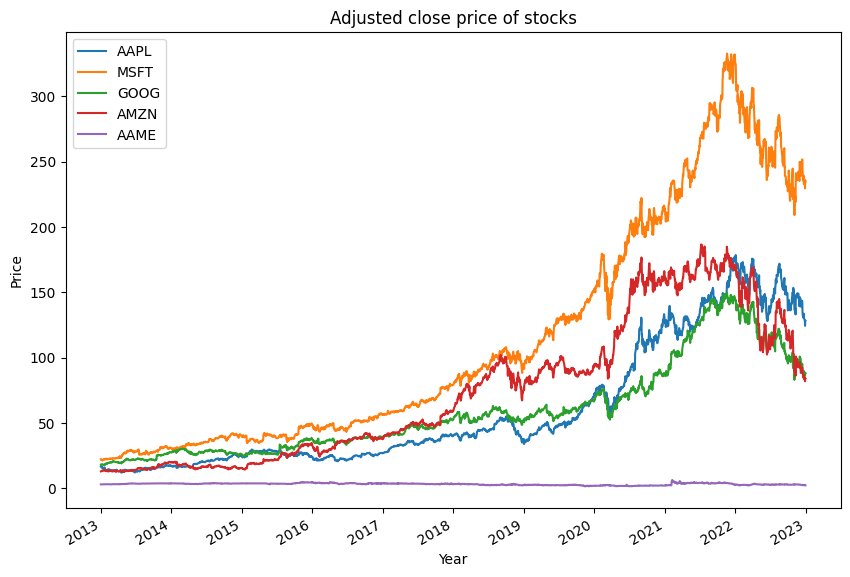

In [ ]:
# Import packages
import yfinance as yf
import pandas as pd

# Set the start and end date
start_date = '2013-01-01'
end_date = '2023-01-01'

# Define the ticker list
tickers_list = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'AAME']

# Create placeholder for data
data = pd.DataFrame(columns=tickers_list)

# Fetch the data
for ticker in tickers_list:
    data[ticker] = yf.download(ticker,
                               start_date,
                               end_date, auto_adjust=False)['Adj Close']

# Print first 5 rows of the data
data.tail()


import matplotlib.pyplot as plt

data.plot(figsize=(10, 7))

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Adjusted close price of stocks')

# Show the plot
plt.show()

Visualization after Normalization

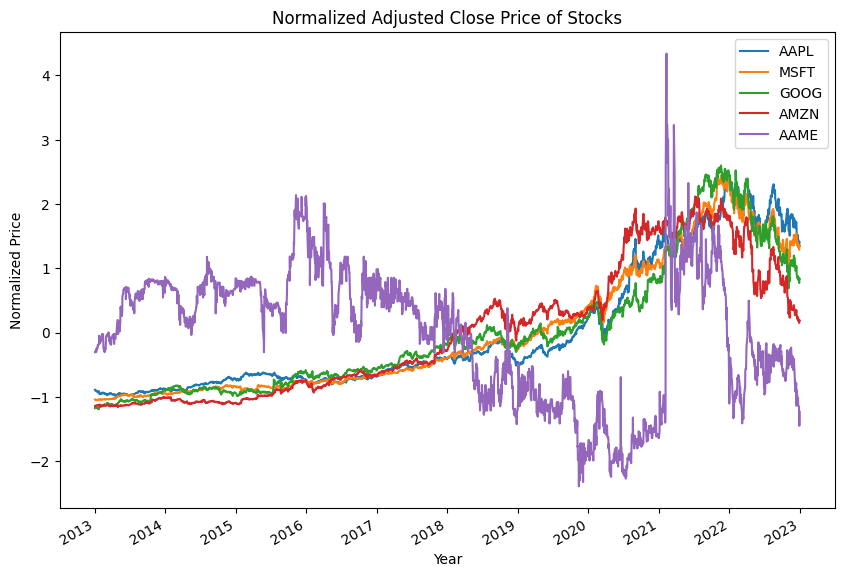

In [ ]:
mean = data.mean(axis=0)
std = data.std(axis=0)
data_normalized = (data - mean) / std

# Plot normalized prices
import matplotlib.pyplot as plt

data_normalized.plot(figsize=(10, 7))

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Normalized Price')
plt.title('Normalized Adjusted Close Price of Stocks')

# Show the plot
plt.show()

Modelling AAME historical stock data using transformers

In [ ]:
# ==========================================
# Stock Price Prediction & Trading Evaluation
# Using Transformer (PyTorch + Yahoo Finance)
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Helper Function: Metrics
# -----------------------------
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100  # avoid division by 0

# -----------------------------
# 2️⃣ Download & Normalize Data
# -----------------------------
stock_symbol = "AAME"
start_date = "2013-01-01"
end_date = "2023-01-01"

stock_data = yf.download(stock_symbol, start=start_date, end=end_date,auto_adjust=False )
stock_data.reset_index(inplace=True)
stock_data.rename(columns={'Adj Close': 'Adjusted Close'}, inplace=True)
stock_data.set_index('Date', inplace=True)

print(stock_data.info())

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2518 entries, 2013-01-02 to 2022-12-30
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Adjusted Close, AAME)  2518 non-null   float64
 1   (Close, AAME)           2518 non-null   float64
 2   (High, AAME)            2518 non-null   float64
 3   (Low, AAME)             2518 non-null   float64
 4   (Open, AAME)            2518 non-null   float64
 5   (Volume, AAME)          2518 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 137.7 KB
None


In [ ]:
columns_to_normalize = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
data_to_normalize = stock_data[columns_to_normalize].values
tensor_data = torch.tensor(data_to_normalize, dtype=torch.float32)

mean = tensor_data.mean(dim=0)
std = tensor_data.std(dim=0)
normalized_data = (tensor_data - mean) / std

df_normalized = pd.DataFrame(normalized_data.numpy(), columns=columns_to_normalize)
df_normalized['Date'] = stock_data.index
data = df_normalized

print(data)


           Low      Open    Volume      High     Close  Adjusted Close  \
0    -0.219206 -0.313870 -0.031703 -0.205243 -0.175703       -0.303657   
1    -0.219206 -0.185497 -0.030824 -0.109179 -0.175703       -0.303657   
2    -0.141041 -0.236846 -0.031923 -0.193235 -0.175703       -0.303657   
3    -0.271316 -0.172660 -0.031176 -0.217251 -0.137200       -0.265288   
4    -0.114986 -0.172660 -0.031571 -0.229259 -0.175703       -0.303657   
...        ...       ...       ...       ...       ...             ...   
2513 -1.105071 -1.186804 -0.032406 -1.189901 -1.176768       -1.124582   
2514 -1.183236 -1.263827 -0.030649 -1.189901 -1.202437       -1.151621   
2515 -1.209291 -1.238153 -0.032626 -1.249941 -1.292276       -1.246256   
2516 -1.404702 -1.276665 -0.029242 -1.273957 -1.484788       -1.449048   
2517 -1.222318 -1.238153 -0.030824 -1.189901 -1.279442       -1.232737   

           Date  
0    2013-01-02  
1    2013-01-03  
2    2013-01-04  
3    2013-01-07  
4    2013-01-08  
...

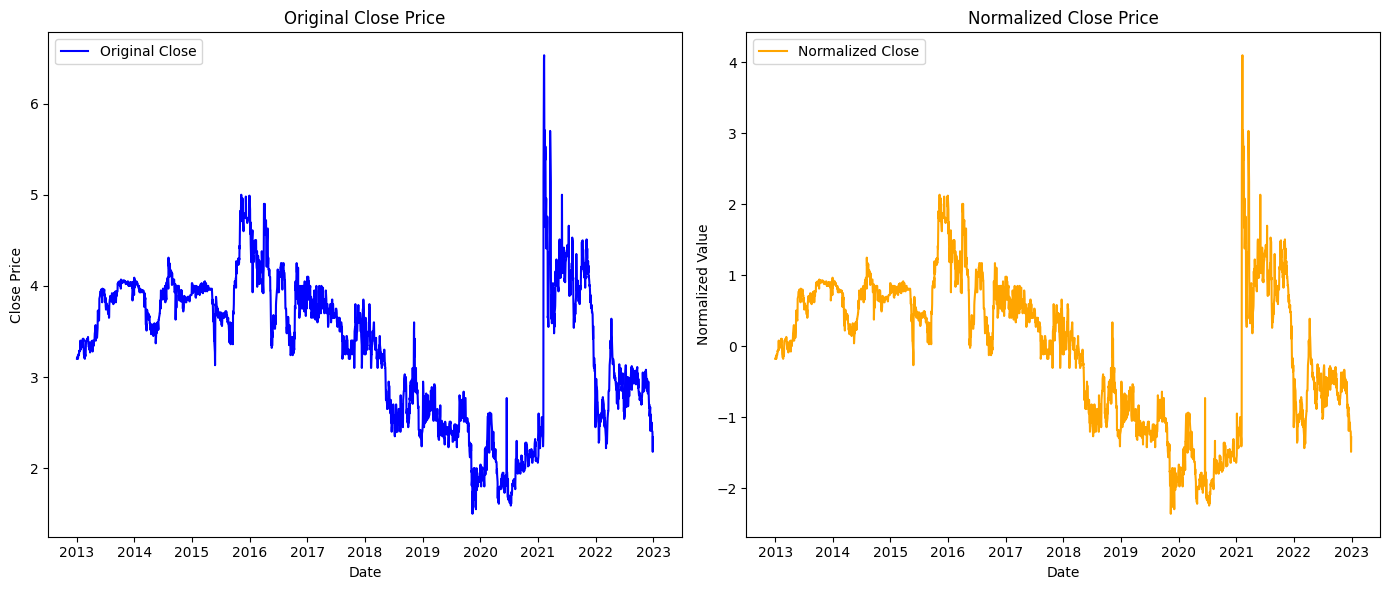

In [ ]:
import matplotlib.pyplot as plt

# Plot original 'Close' price
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(stock_data.index, stock_data['Close'], label='Original Close', color='blue')
plt.title('Original Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()

# Plot normalized 'Close' price
plt.subplot(1, 2, 2)
plt.plot(data['Date'], data['Close'], label='Normalized Close', color='orange')
plt.title('Normalized Close Price')
plt.xlabel('Date')
plt.ylabel('Normalized Value')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Split into Train/Val/Test
train_percent, val_percent = 0.7, 0.15
train_size = int(train_percent * len(data))
val_size = int(val_percent * len(data))
test_size = len(data) - train_size - val_size

train_data = data.iloc[:train_size]
val_data = data.iloc[train_size:train_size + val_size]
test_data = data.iloc[train_size + val_size:]

feature_columns = ['Low', 'Open', 'High', 'Volume']
target_column = 'Close'

In [ ]:

# Create Time-Series Sequences

def create_sequences(features, target, window_size):
    X, y = [], []
    for i in range(len(features) - window_size):
        X.append(features[i:i + window_size])
        y.append(target[i + window_size])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

window_size = 30 # One month

train_X, train_y = create_sequences(train_data[feature_columns].values, train_data[target_column].values, window_size)
val_X, val_y = create_sequences(val_data[feature_columns].values, val_data[target_column].values, window_size)
test_X, test_y = create_sequences(test_data[feature_columns].values, test_data[target_column].values, window_size)


/tmp/ipython-input-487690717.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [ ]:
# Define Transformer Model

class TransformerModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, num_heads):
        super().__init__()
        self.embedding = nn.Linear(input_size, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: [batch, seq_len, features]
        x = self.embedding(x)
        x = x.permute(1, 0, 2)  # [seq_len, batch, hidden]
        x = self.transformer(x)
        x = x[-1, :, :]  # take output from last time step
        out = self.fc_out(x)
        return out

In [ ]:
# Train the Model

input_size = len(feature_columns)
hidden_size = 64
output_size = 1
num_layers = 2
num_heads = 4
learning_rate = 0.001
num_epochs = 80

model = TransformerModel(input_size, hidden_size, output_size, num_layers, num_heads)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(train_X)
    loss = criterion(outputs.squeeze(), train_y)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_outputs = model(val_X)
        val_loss = criterion(val_outputs.squeeze(), val_y)
    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")




/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [10/80] | Train Loss: 0.3029 | Val Loss: 1.3193
Epoch [20/80] | Train Loss: 0.0970 | Val Loss: 0.3536
Epoch [30/80] | Train Loss: 0.0568 | Val Loss: 0.4890
Epoch [40/80] | Train Loss: 0.0450 | Val Loss: 0.3344
Epoch [50/80] | Train Loss: 0.0329 | Val Loss: 0.3108
Epoch [60/80] | Train Loss: 0.0311 | Val Loss: 0.2851
Epoch [70/80] | Train Loss: 0.0304 | Val Loss: 0.2727
Epoch [80/80] | Train Loss: 0.0277 | Val Loss: 0.2612


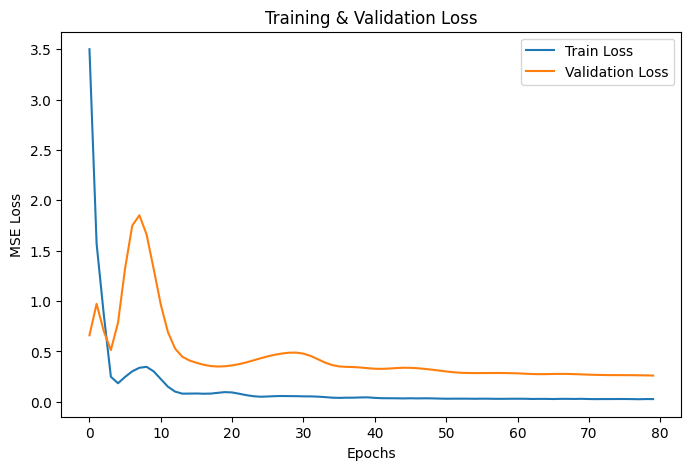


Test Set Metrics:
MAE:  0.1230
MSE:  0.0265
RMSE: 0.1627
MAPE: 26.5362%


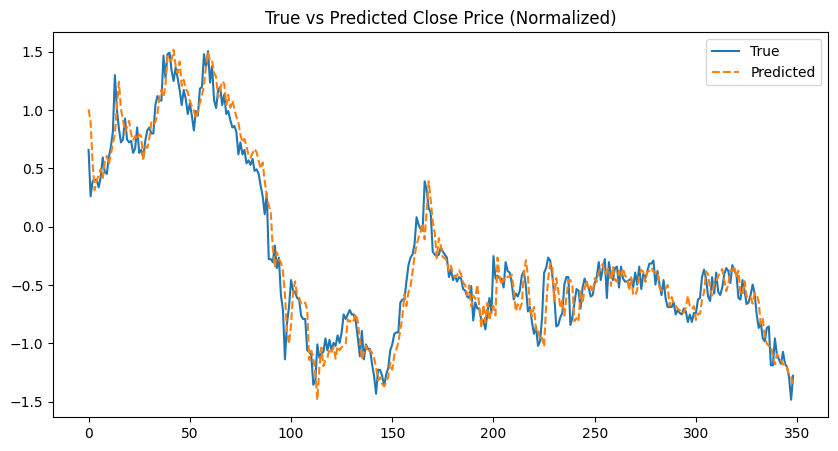

Directional Accuracy: 48.56%


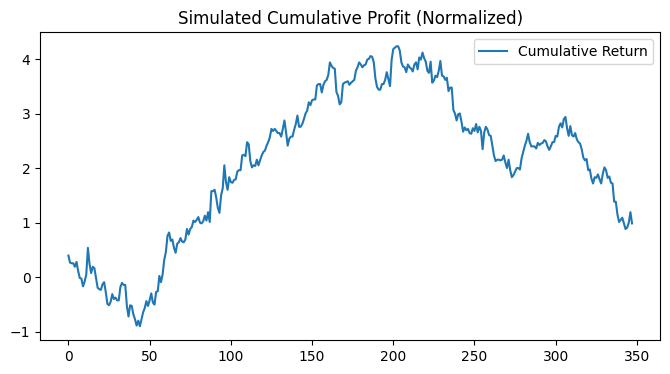

In [ ]:
# Plot training curves
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.show()

# -----------------------------
# 7️⃣ Evaluate on Test Set
# -----------------------------
model.eval()
with torch.no_grad():
    predictions = model(test_X).squeeze().numpy()
    actual = test_y.numpy()

mae = mean_absolute_error(actual, predictions)
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mape = calculate_mape(actual, predictions)

print("\nTest Set Metrics:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

# -----------------------------
# 8️⃣ Plot Predictions vs Actual
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(actual, label='True')
plt.plot(predictions, label='Predicted', linestyle='dashed')
plt.legend()
plt.title('True vs Predicted Close Price (Normalized)')
plt.show()

# -----------------------------
# 9️⃣ Simple Trading Evaluation
# -----------------------------
pred_diff = np.diff(predictions)
true_diff = np.diff(actual)

pred_dir = np.sign(pred_diff)
true_dir = np.sign(true_diff)

direction_accuracy = np.mean(pred_dir == true_dir) * 100
print(f"Directional Accuracy: {direction_accuracy:.2f}%")

# Simulate simple long-only trading strategy
returns = true_diff * pred_dir  # profit when direction is correct
cumulative_return = np.cumsum(returns)

plt.figure(figsize=(8,4))
plt.plot(cumulative_return, label='Cumulative Return')
plt.title('Simulated Cumulative Profit (Normalized)')
plt.legend()
plt.show()

In [ ]:
## For Window size 10

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [10/80] | Train Loss: 0.3391 | Val Loss: 1.4046
Epoch [20/80] | Train Loss: 0.1324 | Val Loss: 0.4176
Epoch [30/80] | Train Loss: 0.0721 | Val Loss: 0.5849
Epoch [40/80] | Train Loss: 0.0540 | Val Loss: 0.3818
Epoch [50/80] | Train Loss: 0.0371 | Val Loss: 0.2953
Epoch [60/80] | Train Loss: 0.0317 | Val Loss: 0.2812
Epoch [70/80] | Train Loss: 0.0291 | Val Loss: 0.2824
Epoch [80/80] | Train Loss: 0.0278 | Val Loss: 0.2716


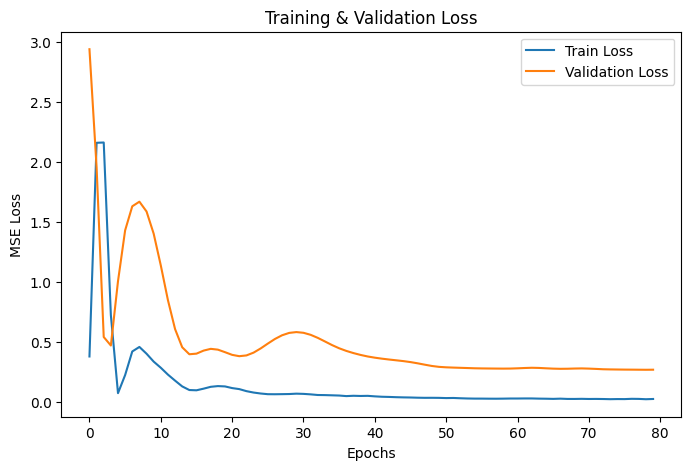


Test Set Metrics:
MAE:  0.1313
MSE:  0.0321
RMSE: 0.1792
MAPE: 28.7036%


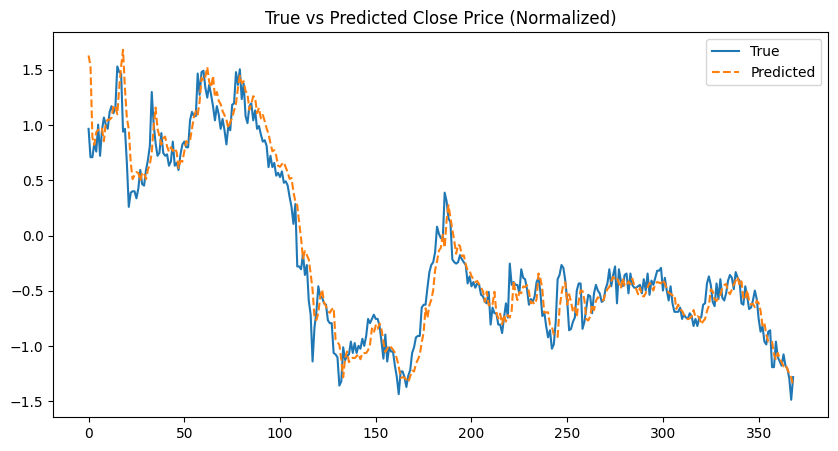

Directional Accuracy: 45.92%


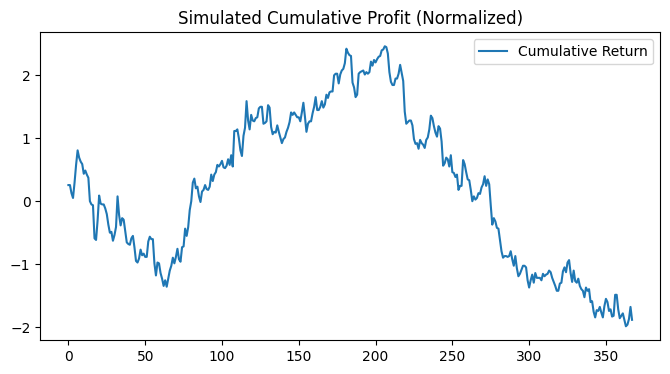

In [ ]:

def create_sequences(features, target, window_size):
    X, y = [], []
    for i in range(len(features) - window_size):
        X.append(features[i:i + window_size])
        y.append(target[i + window_size])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

window_size = 10 # For 10 days

train_X, train_y = create_sequences(train_data[feature_columns].values, train_data[target_column].values, window_size)
val_X, val_y = create_sequences(val_data[feature_columns].values, val_data[target_column].values, window_size)
test_X, test_y = create_sequences(test_data[feature_columns].values, test_data[target_column].values, window_size)


class TransformerModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, num_heads):
        super().__init__()
        self.embedding = nn.Linear(input_size, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: [batch, seq_len, features]
        x = self.embedding(x)
        x = x.permute(1, 0, 2)  # [seq_len, batch, hidden]
        x = self.transformer(x)
        x = x[-1, :, :]  # take output from last time step
        out = self.fc_out(x)
        return out


input_size = len(feature_columns)
hidden_size = 64
output_size = 1
num_layers = 2
num_heads = 4
learning_rate = 0.001
num_epochs = 80

model = TransformerModel(input_size, hidden_size, output_size, num_layers, num_heads)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(train_X)
    loss = criterion(outputs.squeeze(), train_y)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_outputs = model(val_X)
        val_loss = criterion(val_outputs.squeeze(), val_y)
    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.show()

model.eval()
with torch.no_grad():
    predictions = model(test_X).squeeze().numpy()
    actual = test_y.numpy()

mae = mean_absolute_error(actual, predictions)
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mape = calculate_mape(actual, predictions)

print("\nTest Set Metrics:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")


plt.figure(figsize=(10,5))
plt.plot(actual, label='True')
plt.plot(predictions, label='Predicted', linestyle='dashed')
plt.legend()
plt.title('True vs Predicted Close Price (Normalized)')
plt.show()


pred_diff = np.diff(predictions)
true_diff = np.diff(actual)

pred_dir = np.sign(pred_diff)
true_dir = np.sign(true_diff)

direction_accuracy = np.mean(pred_dir == true_dir) * 100
print(f"Directional Accuracy: {direction_accuracy:.2f}%")

# Simulate simple long-only trading strategy
returns = true_diff * pred_dir  # profit when direction is correct
cumulative_return = np.cumsum(returns)

plt.figure(figsize=(8,4))
plt.plot(cumulative_return, label='Cumulative Return')
plt.title('Simulated Cumulative Profit (Normalized)')
plt.legend()
plt.show()


## For Apple stock price data

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [10/80] | Train Loss: 0.1743 | Val Loss: 0.6766
Epoch [20/80] | Train Loss: 0.1131 | Val Loss: 1.5753
Epoch [30/80] | Train Loss: 0.0490 | Val Loss: 0.6589
Epoch [40/80] | Train Loss: 0.0246 | Val Loss: 0.6726
Epoch [50/80] | Train Loss: 0.0163 | Val Loss: 0.5171
Epoch [60/80] | Train Loss: 0.0119 | Val Loss: 0.7037
Epoch [70/80] | Train Loss: 0.0096 | Val Loss: 0.6754
Epoch [80/80] | Train Loss: 0.0088 | Val Loss: 0.6804


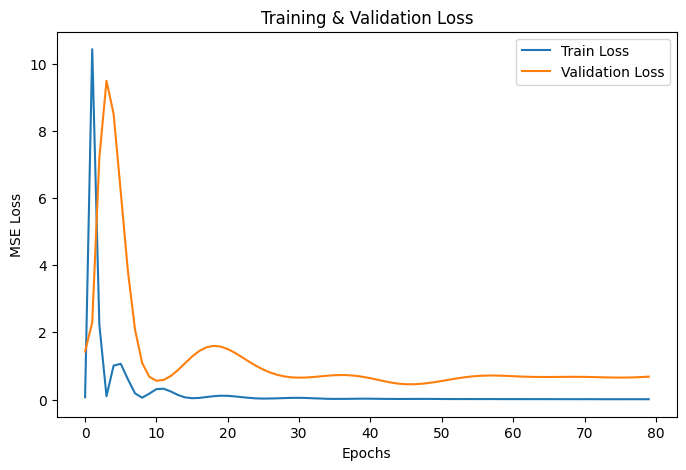


Test Set Metrics:
MAE:  1.6292
MSE:  2.7182
RMSE: 1.6487
MAPE: 86.0709%


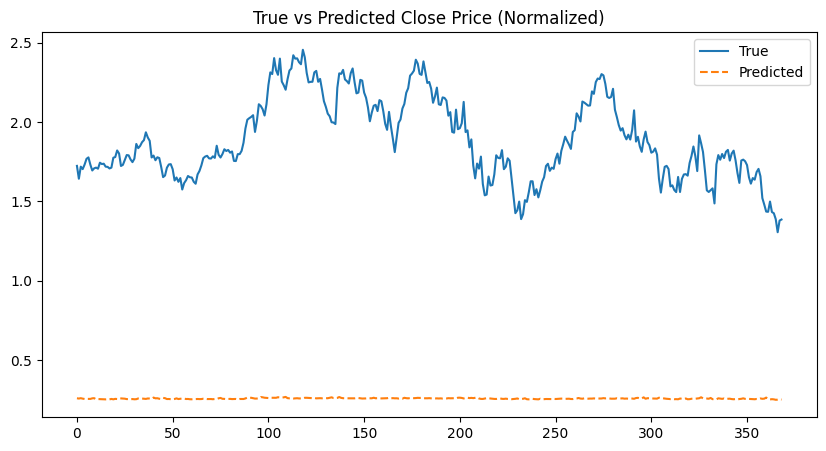

Directional Accuracy: 44.57%


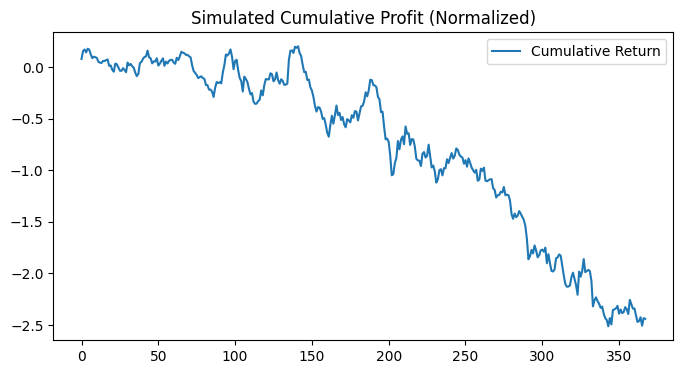

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100  # avoid division by 0


stock_symbol = "AAPL"
start_date = "2013-01-01"
end_date = "2023-01-01"

stock_data = yf.download(stock_symbol, start=start_date, end=end_date,auto_adjust=False )
stock_data.reset_index(inplace=True)
stock_data.rename(columns={'Adj Close': 'Adjusted Close'}, inplace=True)
stock_data.set_index('Date', inplace=True)

columns_to_normalize = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
data_to_normalize = stock_data[columns_to_normalize].values
tensor_data = torch.tensor(data_to_normalize, dtype=torch.float32)

mean = tensor_data.mean(dim=0)
std = tensor_data.std(dim=0)
normalized_data = (tensor_data - mean) / std

df_normalized = pd.DataFrame(normalized_data.numpy(), columns=columns_to_normalize)
df_normalized['Date'] = stock_data.index
data = df_normalized


train_percent, val_percent = 0.7, 0.15
train_size = int(train_percent * len(data))
val_size = int(val_percent * len(data))
test_size = len(data) - train_size - val_size

train_data = data.iloc[:train_size]
val_data = data.iloc[train_size:train_size + val_size]
test_data = data.iloc[train_size + val_size:]

feature_columns = ['Low', 'Open', 'High', 'Volume']
target_column = 'Close'


def create_sequences(features, target, window_size):
    X, y = [], []
    for i in range(len(features) - window_size):
        X.append(features[i:i + window_size])
        y.append(target[i + window_size])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

window_size = 10

train_X, train_y = create_sequences(train_data[feature_columns].values, train_data[target_column].values, window_size)
val_X, val_y = create_sequences(val_data[feature_columns].values, val_data[target_column].values, window_size)
test_X, test_y = create_sequences(test_data[feature_columns].values, test_data[target_column].values, window_size)


class TransformerModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, num_heads):
        super().__init__()
        self.embedding = nn.Linear(input_size, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: [batch, seq_len, features]
        x = self.embedding(x)
        x = x.permute(1, 0, 2)  # [seq_len, batch, hidden]
        x = self.transformer(x)
        x = x[-1, :, :]  # take output from last time step
        out = self.fc_out(x)
        return out

input_size = len(feature_columns)
hidden_size = 64
output_size = 1
num_layers = 2
num_heads = 4
learning_rate = 0.001
num_epochs = 80

model = TransformerModel(input_size, hidden_size, output_size, num_layers, num_heads)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(train_X)
    loss = criterion(outputs.squeeze(), train_y)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_outputs = model(val_X)
        val_loss = criterion(val_outputs.squeeze(), val_y)
    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

# Plot training curves
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.show()


model.eval()
with torch.no_grad():
    predictions = model(test_X).squeeze().numpy()
    actual = test_y.numpy()

mae = mean_absolute_error(actual, predictions)
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mape = calculate_mape(actual, predictions)

print("\nTest Set Metrics:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")


plt.figure(figsize=(10,5))
plt.plot(actual, label='True')
plt.plot(predictions, label='Predicted', linestyle='dashed')
plt.legend()
plt.title('True vs Predicted Close Price (Normalized)')
plt.show()


pred_diff = np.diff(predictions)
true_diff = np.diff(actual)

pred_dir = np.sign(pred_diff)
true_dir = np.sign(true_diff)

direction_accuracy = np.mean(pred_dir == true_dir) * 100
print(f"Directional Accuracy: {direction_accuracy:.2f}%")

# Simulate simple long-only trading strategy
returns = true_diff * pred_dir  # profit when direction is correct
cumulative_return = np.cumsum(returns)

plt.figure(figsize=(8,4))
plt.plot(cumulative_return, label='Cumulative Return')
plt.title('Simulated Cumulative Profit (Normalized)')
plt.legend()
plt.show()
